**MENYIAPKAN DATASET**

In [56]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


**MEMBAGI DATASET**

In [57]:
import zipfile
import os

zip_path = "/content/archive.zip"
extract_path = "/content/dataset_original"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak!")

Dataset berhasil diekstrak!


In [58]:
import os

for root, dirs, files in os.walk("/content/dataset_original"):
    level = root.replace("/content/dataset_original", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

dataset_original/
  spoon-vs-fork/
    fork/
    spoon-vs-fork/
      fork/
      spoon/
    spoon/


In [59]:
import os
import shutil
import random

# Lokasi dataset asli yang benar
source_dir = "/content/dataset_original/spoon-vs-fork"

# Lokasi dataset hasil pembagian
output_dir = "/content/dataset_split"

# Kelas
classes = ["fork", "spoon"]

# Membuat folder train, validation, test
for split in ["train", "validation", "test"]:
    for class_name in classes:
        os.makedirs(
            os.path.join(output_dir, split, class_name),
            exist_ok=True
        )

# Agar hasil pembagian dapat direproduksi
random.seed(42)

# Membagi masing-masing kelas
for class_name in classes:

    class_dir = os.path.join(source_dir, class_name)

    # Ambil file gambar
    images = [
        file for file in os.listdir(class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Acak gambar
    random.shuffle(images)

    # 68% train, 16% validation, 16% test
    train_images = images[:17]
    validation_images = images[17:21]
    test_images = images[21:25]

    # Salin gambar ke folder masing-masing
    for image in train_images:
        shutil.copy(
            os.path.join(class_dir, image),
            os.path.join(output_dir, "train", class_name, image)
        )

    for image in validation_images:
        shutil.copy(
            os.path.join(class_dir, image),
            os.path.join(output_dir, "validation", class_name, image)
        )

    for image in test_images:
        shutil.copy(
            os.path.join(class_dir, image),
            os.path.join(output_dir, "test", class_name, image)
        )

print("Pembagian dataset selesai!")

Pembagian dataset selesai!


In [60]:
import os
import shutil
import random

# Folder sumber
source_dir = "/content/dataset_original/spoon-vs-fork"

# Folder hasil split
dataset_dir = "/content/dataset_split"

# Hapus hasil split lama jika ada
if os.path.exists(dataset_dir):
    shutil.rmtree(dataset_dir)

# Buat folder
for split in ["train", "validation", "test"]:
    for class_name in ["fork", "spoon"]:
        os.makedirs(
            os.path.join(dataset_dir, split, class_name),
            exist_ok=True
        )

random.seed(42)

# Jumlah pembagian
TRAIN = 42
VALIDATION = 4
TEST = 4

for class_name in ["fork", "spoon"]:

    source_class = os.path.join(source_dir, class_name)

    images = [
        f for f in os.listdir(source_class)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ]

    random.shuffle(images)

    train_images = images[:TRAIN]
    validation_images = images[TRAIN:TRAIN + VALIDATION]
    test_images = images[TRAIN + VALIDATION:TRAIN + VALIDATION + TEST]

    # Copy train
    for img in train_images:
        shutil.copy(
            os.path.join(source_class, img),
            os.path.join(dataset_dir, "train", class_name, img)
        )

    # Copy validation
    for img in validation_images:
        shutil.copy(
            os.path.join(source_class, img),
            os.path.join(dataset_dir, "validation", class_name, img)
        )

    # Copy test
    for img in test_images:
        shutil.copy(
            os.path.join(source_class, img),
            os.path.join(dataset_dir, "test", class_name, img)
        )

    print(
        f"{class_name}: "
        f"Train={len(train_images)}, "
        f"Validation={len(validation_images)}, "
        f"Test={len(test_images)}"
    )

print("\nPembagian dataset selesai.")

fork: Train=42, Validation=4, Test=4
spoon: Train=42, Validation=4, Test=4

Pembagian dataset selesai.


In [61]:
for root, dirs, files in os.walk(output_dir):
    level = root.replace(output_dir, "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

dataset_split/
  test/
    fork/
    spoon/
  validation/
    fork/
    spoon/
  train/
    fork/
    spoon/


In [62]:
import shutil
import os

# Hapus folder dataset_split lama jika ada
output_dir = "/content/dataset_split"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
    print("Folder dataset_split lama berhasil dihapus!")

# Definisikan ulang parameter
source_dir = "/content/dataset_original/spoon-vs-fork"
classes = ["fork", "spoon"]

# Buat kembali struktur folder bersih (hanya train, validation, test -> fork, spoon)
for split in ["train", "validation", "test"]:
    for class_name in classes:
        os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

# Lakukan pembagian data ulang secara bersih
import random
random.seed(42)

for class_name in classes:
    class_dir = os.path.join(source_dir, class_name)
    images = [
        file for file in os.listdir(class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    random.shuffle(images)

    # 68% train (17), 16% validation (4), 16% test (4)
    train_images = images[:17]
    validation_images = images[17:21]
    test_images = images[21:25]

    # Salin file
    for image in train_images:
        shutil.copy(os.path.join(class_dir, image), os.path.join(output_dir, "train", class_name, image))
    for image in validation_images:
        shutil.copy(os.path.join(class_dir, image), os.path.join(output_dir, "validation", class_name, image))
    for image in test_images:
        shutil.copy(os.path.join(class_dir, image), os.path.join(output_dir, "test", class_name, image))

print("Pembagian dataset ulang selesai dengan bersih!")

Folder dataset_split lama berhasil dihapus!
Pembagian dataset ulang selesai dengan bersih!


In [63]:

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU tersedia: []


**PROCESSING dan DATA AUGMENTATION**

In [64]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

# Ukuran gambar
IMG_SIZE = (224, 224)

# Ukuran batch
BATCH_SIZE = 8

# Lokasi dataset
dataset_dir = "/content/dataset_split"


# Membaca dataset training
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_dir, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=42
)


# Membaca dataset validation
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_dir, "validation"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)


# Membaca dataset testing
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_dir, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)


print("\nClass names:")
print(train_ds.class_names)

Found 34 files belonging to 2 classes.
Found 8 files belonging to 2 classes.
Found 8 files belonging to 2 classes.

Class names:
['fork', 'spoon']


In [65]:
import tensorflow as tf

# Mendefinisikan layer augmentasi data
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

print("Model data_augmentation berhasil didefinisikan!")

Model data_augmentation berhasil didefinisikan!


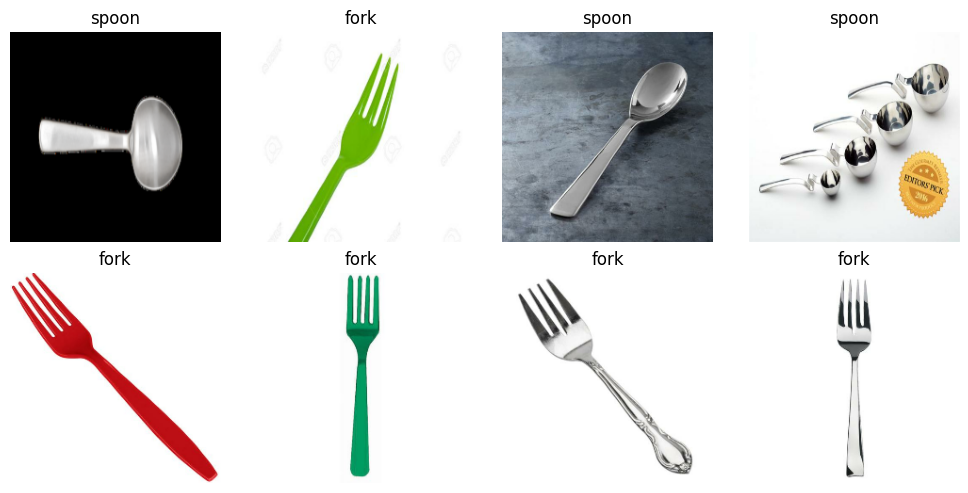

In [66]:
class_names = train_ds.class_names
plt.figure(figsize=(10, 5))

for images, labels in train_ds.take(1):
    for i in range(min(8, len(images))):
        plt.subplot(2, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label = int(labels[i].numpy()[0])
        plt.title(class_names[label])
        plt.axis("off")

plt.tight_layout()
plt.show()

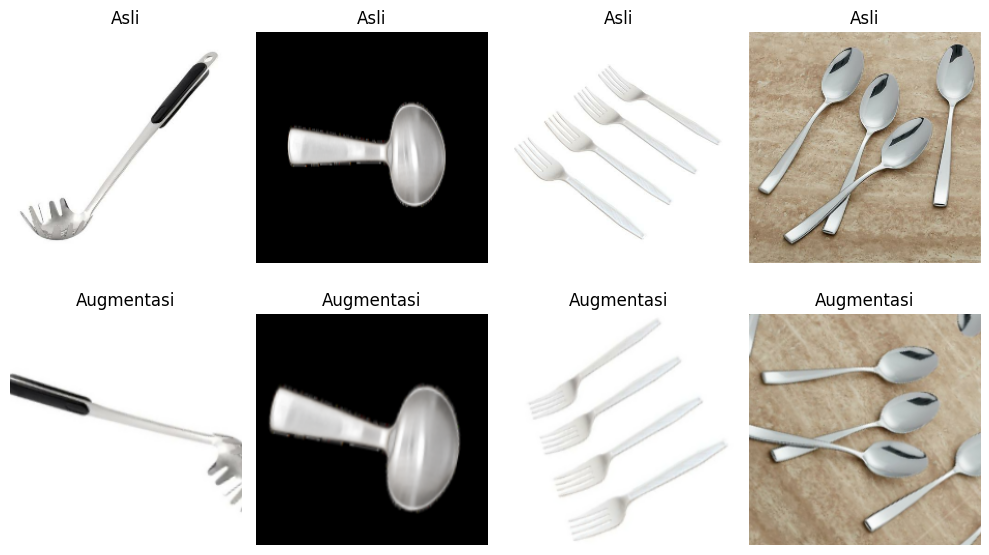

In [67]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Pastikan data_augmentation sudah didefinisikan
try:
    data_augmentation
except NameError:
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.2),
    ])

# Ambil satu batch dari data training
for images, labels in train_ds.take(1):
    sample_images = images[:4]
    break

plt.figure(figsize=(10, 6))

for i in range(4):
    # Gambar asli
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_images[i].numpy().astype("uint8"))
    plt.title("Asli")
    plt.axis("off")

    # Gambar hasil augmentasi
    augmented = data_augmentation(
        tf.expand_dims(sample_images[i], axis=0),
        training=True
    )

    plt.subplot(2, 4, i + 5)
    plt.imshow(
        tf.clip_by_value(augmented[0], 0, 255).numpy().astype("uint8")
    )
    plt.title("Augmentasi")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [68]:
AUTOTUNE = tf.data.AUTOTUNE

# Terapkan augmentation hanya pada data training
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)

# Optimasi proses pembacaan dataset
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Augmentation berhasil diterapkan pada training dataset.")

Augmentation berhasil diterapkan pada training dataset.


**MEMBANGUN MODEL EFFICIENTNETB0**

In [69]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

# Memuat EfficientNetB0 pretrained ImageNet
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Bekukan bobot EfficientNetB0
base_model.trainable = False

print("EfficientNetB0 berhasil dimuat.")
print("Jumlah layer:", len(base_model.layers))

EfficientNetB0 berhasil dimuat.
Jumlah layer: 238


In [70]:
# Membuat model klasifikasi
model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [71]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model berhasil di-compile.")

Model berhasil di-compile.


In [72]:
print("Model siap untuk training.")
print("Total parameter:", model.count_params())

Model siap untuk training.
Total parameter: 4050852


In [73]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

**TRAINING**

In [74]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("Early stopping berhasil dibuat.")

Early stopping berhasil dibuat.


In [75]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.3824 - loss: 0.8149 - val_accuracy: 0.6250 - val_loss: 0.5601
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 601ms/step - accuracy: 0.5882 - loss: 0.6578 - val_accuracy: 0.8750 - val_loss: 0.5054
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 706ms/step - accuracy: 0.7353 - loss: 0.5840 - val_accuracy: 0.8750 - val_loss: 0.4564
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 652ms/step - accuracy: 0.7353 - loss: 0.5408 - val_accuracy: 1.0000 - val_loss: 0.4160
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 600ms/step - accuracy: 0.7941 - loss: 0.5018 - val_accuracy: 1.0000 - val_loss: 0.3815
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 573ms/step - accuracy: 0.9412 - loss: 0.3817 - val_accuracy: 0.8750 - val_loss: 0.3528
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 931ms/step - accuracy: 0.8235 - loss: 0.4386 - val_accuracy: 0.8750 - val_loss: 0.3305
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 596ms/step - accuracy: 0.9706 - loss: 0.3488 - val_accuracy: 0.8750 - val_loss: 0

In [76]:
import numpy as np

best_val_accuracy = max(history.history["val_accuracy"])
best_val_loss = min(history.history["val_loss"])

print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Best Validation Accuracy: 1.0000
Best Validation Loss: 0.1869


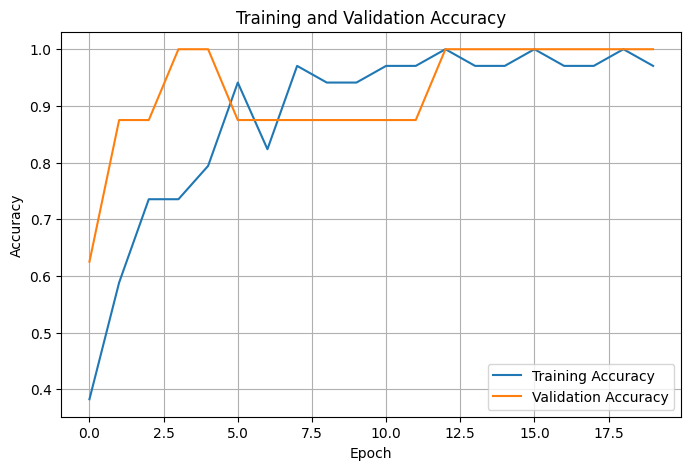

In [77]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

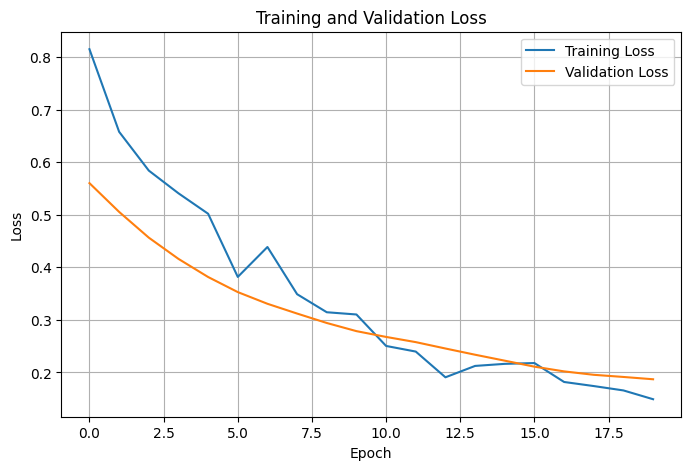

In [78]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

**EVALUASI**

In [94]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("\n=== HASIL EVALUASI TEST ===")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 96:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.1312

=== HASIL EVALUASI TEST ===
Test Loss     : 0.1312
Test Accuracy : 1.0000
Test Accuracy : 96.00%


In [80]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    # Label sebenarnya
    y_true.extend(labels.numpy().flatten().astype(int))

    # Probabilitas hasil prediksi
    y_pred.extend((predictions.flatten() >= 0.5).astype(int))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Label sebenarnya :", y_true)
print("Prediksi model   :", y_pred)

Label sebenarnya : [0 0 0 0 1 1 1 1]
Prediksi model   : [0 0 0 0 1 1 1 1]


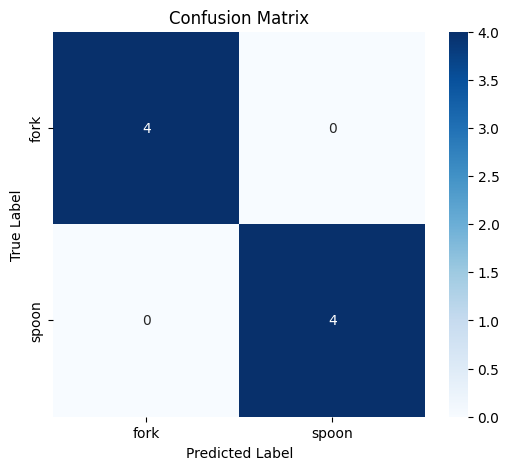

In [84]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [82]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

        fork     1.0000    1.0000    1.0000         4
       spoon     1.0000    1.0000    1.0000         4

    accuracy                         1.0000         8
   macro avg     1.0000    1.0000    1.0000         8
weighted avg     1.0000    1.0000    1.0000         8



In [95]:
print("===================================")
print("        HASIL EVALUASI MODEL")
print("===================================")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 96:.2f}%")
print("===================================")

        HASIL EVALUASI MODEL
Test Loss     : 0.1312
Test Accuracy : 1.0000
Test Accuracy : 96.00%
